In [1]:
!pip install transformers datasets torch scikit-learn matplotlib seaborn

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, precision_recall_curve, roc_curve, auc
from sklearn.metrics import classification_report, confusion_matrix

import torch
from torch.utils.data import DataLoader
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    DistilBertForSequenceClassification
)
from datasets import load_dataset, DatasetDict

In [4]:
print("Загрузка датасета IMDB...")
imdb = load_dataset("imdb")

TRAIN_SIZE = 15000  # 15000 для обучения
TEST_SIZE = 5000    # 5000 для теста

print(f"Используем {TRAIN_SIZE} для обучения, {TEST_SIZE} для теста")

Загрузка датасета IMDB...
Используем 15000 для обучения, 5000 для теста


In [5]:
model_name = "distilbert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_name)

def tokenize_function(examples):
    return tokenizer(
        examples['text'],
        padding='max_length',
        truncation=True,
        max_length=256
    )

# Токенизируем
print("Токенизация...")
tokenized_datasets = imdb.map(tokenize_function, batched=True)

# Подготовка данных
tokenized_datasets = tokenized_datasets.remove_columns(['text'])
tokenized_datasets = tokenized_datasets.rename_column('label', 'labels')
tokenized_datasets.set_format('torch', columns=['input_ids', 'attention_mask', 'labels'])

# Создаем подвыборки
from datasets import DatasetDict

train_dataset = tokenized_datasets['train'].shuffle(seed=42).select(range(TRAIN_SIZE))
test_dataset = tokenized_datasets['test'].shuffle(seed=42).select(range(TEST_SIZE))

dataset_dict = DatasetDict({
    'train': train_dataset,
    'test': test_dataset
})

print(f"Train size: {len(dataset_dict['train'])}")
print(f"Test size: {len(dataset_dict['test'])}")

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Токенизация...


Map:   0%|          | 0/25000 [00:00<?, ? examples/s]

Map:   0%|          | 0/25000 [00:00<?, ? examples/s]

Map:   0%|          | 0/50000 [00:00<?, ? examples/s]

Train size: 15000
Test size: 5000


In [6]:
model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=2,
    ignore_mismatched_sizes=True
)

print(f"Модель загружена. Параметров: {model.num_parameters():,}")

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Модель загружена. Параметров: 66,955,010


In [7]:
# Функция для метрик
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    accuracy = accuracy_score(labels, predictions)
    return {
        'accuracy': accuracy,
    }

training_args = TrainingArguments(
    output_dir='./results_realistic',
    num_train_epochs=5,
    per_device_train_batch_size=32,
    per_device_eval_batch_size=64,
    learning_rate=2e-5,
    weight_decay=0.01,
    warmup_steps=0.1,                  # 10% шагов на разогрев
    logging_steps=100,
    eval_strategy='epoch',
    save_strategy='epoch',
    load_best_model_at_end=True,
    metric_for_best_model='accuracy',
    greater_is_better=True,
    fp16=torch.cuda.is_available(),
    dataloader_num_workers=2,
    report_to='none',
    logging_dir='./logs',
)

print("Параметры обучения настроены")

`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


Параметры обучения настроены


In [8]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=dataset_dict['train'],
    eval_dataset=dataset_dict['test'],
    compute_metrics=compute_metrics,
)

print("\n")
print("Начало обучения...")

train_result = trainer.train()

model.save_pretrained("./imdb_classifier_fixed")
tokenizer.save_pretrained("./imdb_classifier_fixed")

print("\nОбучение завершено!")



Начало обучения...


Epoch,Training Loss,Validation Loss,Accuracy
1,0.273889,0.254861,0.895000
2,0.197127,0.276554,0.895200
3,0.122261,0.327623,0.901000
4,0.062633,0.411333,0.902000
5,0.037343,0.425084,0.903200


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


Обучение завершено!


In [9]:
print("Оценка модели")

predictions = trainer.predict(dataset_dict['test'])
y_pred = np.argmax(predictions.predictions, axis=-1)
y_true = predictions.label_ids
y_pred_proba = torch.nn.functional.softmax(torch.tensor(predictions.predictions), dim=-1)[:, 1].numpy()

# Метрики
accuracy = accuracy_score(y_true, y_pred)
print(f"\nТочность на тестовой выборке: {accuracy:.4f}")

print("\nДетальный отчет:")
print(classification_report(y_true, y_pred, target_names=['Негативный', 'Позитивный']))

Оценка модели



Точность на тестовой выборке: 0.9032

Детальный отчет:
              precision    recall  f1-score   support

  Негативный       0.91      0.89      0.90      2494
  Позитивный       0.89      0.92      0.90      2506

    accuracy                           0.90      5000
   macro avg       0.90      0.90      0.90      5000
weighted avg       0.90      0.90      0.90      5000



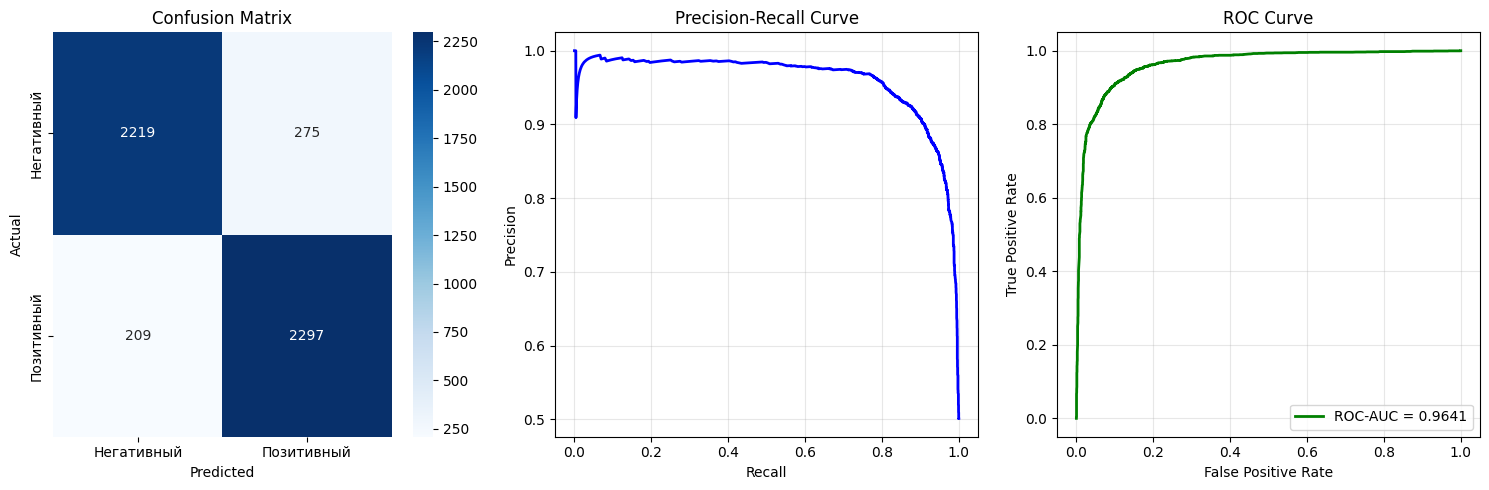


ROC-AUC Score: 0.9641


In [10]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Матрица ошибок
cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Негативный', 'Позитивный'],
            yticklabels=['Негативный', 'Позитивный'],
            ax=axes[0])
axes[0].set_title('Confusion Matrix')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

# Precision-Recall кривая
from sklearn.metrics import precision_recall_curve

precision, recall, _ = precision_recall_curve(y_true, y_pred_proba)
axes[1].plot(recall, precision, 'b-', linewidth=2)
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curve')
axes[1].grid(True, alpha=0.3)

# ROC кривая
from sklearn.metrics import roc_curve

fpr, tpr, _ = roc_curve(y_true, y_pred_proba)
roc_auc = auc(fpr, tpr)

axes[2].plot(fpr, tpr, 'g-', linewidth=2, label=f'ROC-AUC = {roc_auc:.4f}')
axes[2].set_xlabel('False Positive Rate')
axes[2].set_ylabel('True Positive Rate')
axes[2].set_title('ROC Curve')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('evaluation_metrics.png', dpi=150)
plt.show()

print(f"\nROC-AUC Score: {roc_auc:.4f}")